In [3]:
from nltk.stem import WordNetLemmatizer 
import nltk 
nltk.download('wordnet') # download WordNet only once 
lemmatizer = WordNetLemmatizer() 

# Words to lemmatize 
words = ["dogs", "cats", "running", "ate"] 

# Lemmatize each word 
for word in words: 

    print(word, "→", lemmatizer.lemmatize(word))

dogs → dog
cats → cat
running → running
ate → ate


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ander\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
from nltk.stem import PorterStemmer 
ps = PorterStemmer() 
words = ["running", "jumps", "easily", "fairly"] 
stemmed_words = [ps.stem(word) for word in words] 
print("Stemmed Words:", stemmed_words)

Stemmed Words: ['run', 'jump', 'easili', 'fairli']


In [5]:
import nltk 
nltk.download('punkt_tab') 
from nltk.tokenize import sent_tokenize 
nltk.download('stopwords') 
text = "NLP is very interesting! It helps machines understand human language." 
sentences = sent_tokenize(text) 

print("Sentences:", sentences)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ander\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ander\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sentences: ['NLP is very interesting!', 'It helps machines understand human language.']


In [6]:
import nltk 
nltk.download('punkt_tab') 
from nltk.tokenize import word_tokenize 
nltk.download('stopwords') 
text = "NLP is very interesting! It helps machines understand human language." 
words = word_tokenize(text) 

print("Words:", words)

Words: ['NLP', 'is', 'very', 'interesting', '!', 'It', 'helps', 'machines', 'understand', 'human', 'language', '.']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ander\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ander\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


header: 
          date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1  1873-03-08   England  Scotland           4           2   Friendly   London   
2  1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3  1875-03-06   England  Scotland           2           2   Friendly   London   
4  1876-03-04  Scotland   England           3           0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  
rows with missing data:  0
tuples:  42650
different tourneys:  120
Games in 2018: 908
home_result
Win     20739
Loss    12074
Draw     9837
Name: count, dtype: int64


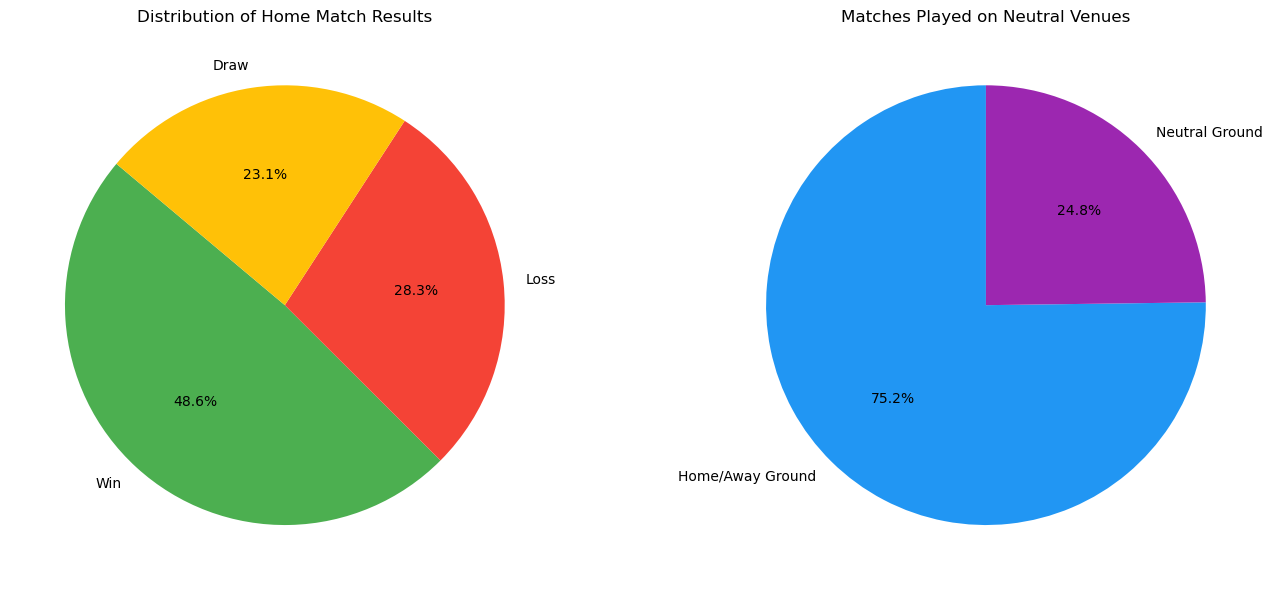

In [37]:
#---FOOTBALL---

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#--- STEP 2---
df = pd.read_csv('football.csv')

print( 'header: \n', df.head(5))

total_rows_with_missing = df.isnull().any(axis=1).sum()
print ('rows with missing data: ', total_rows_with_missing)

#---STEP 3---
print('tuples: ', len(df))

print('different tourneys: ', df['tournament'].nunique())

#---STEP4 ---
df['date'] = pd.to_datetime(df['date'])

count_2018 = (df['date'].dt.year == 2018).sum()

print('Games in 2018:', count_2018)

#---STEP 5---
conditions = [
    df['home_score'] > df['away_score'],
    df['home_score'] < df['away_score'],
    df['home_score'] == df['away_score']
]


choices = ['Win', 'Loss', 'Draw']


df['home_result'] = np.select(conditions, choices, default='Draw')
counts = df['home_result'].value_counts()
print(counts)


#---STEP 6---
result_counts = df["home_result"].value_counts()
neutral_counts = df["neutral"].value_counts()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Home Results
axes[0].pie(
    result_counts,
    labels=result_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4CAF50", "#F44336", "#FFC107"],  # Green, Red, Yellow
)
axes[0].set_title("Distribution of Home Match Results")


neutral_labels = [
    "Neutral Ground" if x else "Home/Away Ground" for x in neutral_counts.index
]

axes[1].pie(
    neutral_counts,
    labels=neutral_labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2196F3", "#9C27B0"],  # Blue, Purple
)
axes[1].set_title("Matches Played on Neutral Venues")


plt.tight_layout()
plt.show()


In [9]:
%pwd


'C:\\Users\\ander'